In [ ]:
# Example of Standalone Simple Linear Regression
from math import sqrt
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-poster')

# Calculate root mean squared error
def rmse_metric(actual, predicted):
    sum_error = 0.0
    for i in range(len(actual)):
        prediction_error = predicted[i] - actual[i]
        sum_error += (prediction_error ** 2)
    mean_error = sum_error / float(len(actual))
    return sqrt(mean_error)


# Evaluate regression algorithm on training dataset
def evaluate_algorithm(dataset, algorithm):
    test_set = list()
    for row in dataset:
        row_copy = list(row)
        row_copy[-1] = None
        test_set.append(row_copy)
    predicted = algorithm(dataset, test_set)
    # print(predicted)
    actual = [row[-1] for row in dataset]
    rmse = rmse_metric(actual, predicted)
    test_x = np.array(test_set)[:, 0]
    plt.scatter(test_x, actual, label="actual", color="red")
    plt.legend()
    return rmse


# Calculate the mean value of a list of numbers
def mean(values):
    return sum(values) / float(len(values))


# Calculate covariance between x and y
def covariance(x, mean_x, y, mean_y):
    covar = 0.0
    for i in range(len(x)):
        covar += (x[i] - mean_x) * (y[i] - mean_y)
    return covar


# Calculate the variance of a list of numbers
def variance(values, mean):
    return sum([(x - mean) ** 2 for x in values])


# Calculate coefficients
def coefficients(dataset):
    dataset = [[3.6, 9.3],[4.8, 10.2],[7.2, 11.5],[6.9, 12],[10.7, 18.6], [6.1, 13.2], [7.9, 10.8], [9.5, 22.7], [5.4, 12.7]]
    x = [row[0] for row in dataset]
    y = [row[1] for row in dataset]
    x_mean, y_mean = mean(x), mean(y)
    b1 = covariance(x, x_mean, y, y_mean) / variance(x, x_mean)
    b0 = y_mean - b1 * x_mean

    xx = np.linspace(0, 1, 101)
    plt.plot(xx, b1 * xx + b0, label="linear model", color="blue")
    print("b0={:.3f}, b1={:.3f}".format(b0, b1))
    return [b0, b1]


# Apply OLR on uni-dim X

1D case: 1D X and 1D Y



b0=1.015, b1=1.474


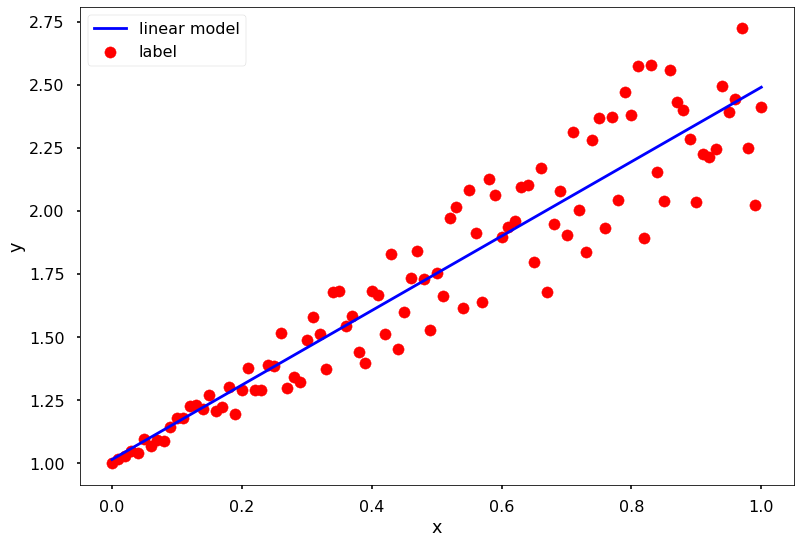

In [ ]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

plt.style.use('seaborn-poster')

# generate x and y
x = np.linspace(0, 1, 101)
y = 1 + x + x * np.random.random(len(x))

# assemble matrix A
A = np.vstack([np.ones(len(x)),x]).T

# turn y into a column vector
y = y[:, np.newaxis]

# Direct least square regression

alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T,A)),A.T)),y)
print("b0={:.3f}, b1={:.3f}".format(alpha[0][0], alpha[1][0]))


# plot the results
plt.scatter(x, y, label="label", color='red')
plt.plot(x, alpha[1]*x + alpha[0], label="linear model", color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Apply OLR on multi-dim X

3D case: 2D X and 1D Y



[[0.8]
 [0.4]]


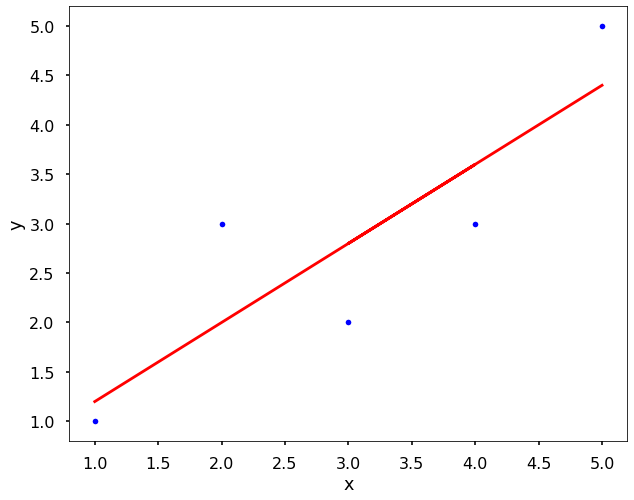

In [ ]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

plt.style.use('seaborn-poster')

# generate x and y
# x = np.linspace(0, 1, 101)
# y = 1 + x + x * np.random.random(len(x))

dataset = [[1, 1], [2, 3], [4, 3], [3, 2], [5, 5]]
x = np.array(dataset)[:,0]
y = np.array(dataset)[:,1]

# assemble matrix A
A = np.vstack([x, np.ones(len(x))]).T

# turn y into a column vector
y = y[:, np.newaxis]

# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T,A)),A.T)),y)
print(alpha)

# plot the results
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, alpha[0]*x + alpha[1], 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

multi-dim X

In [1]:
import plotly.express as px
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Dataset
X = [[150, 100], [159, 200], [170, 350], [175, 400], [179, 500], [180, 180], [189, 159], [199, 110], [199, 400],
     [199, 230], [235, 120], [239, 340], [239, 360], [249, 145], [249, 400]]
Y = [0.73, 1.39, 2.03, 1.45, 1.82, 1.32, 0.83, 0.53, 1.95, 1.27, 0.49, 1.03, 1.24, 0.55, 1.3]
df2 = pd.DataFrame(X, columns=['Price', 'AdSpends'])
df2['Sales'] = pd.Series(Y)

X = np.array(X)
Y = np.array(Y)
## learn the plane (linear surface)
# assemble matrix A
A = np.hstack([X, np.ones([len(Y), 1])])
# turn y into a column vector
y = Y[:, np.newaxis]

# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T, A)), A.T)), y)
print(alpha)

x = np.linspace(150, 250, 100)
y = np.linspace(100, 500, 100)
X, Y = np.meshgrid(x, y)
Z = alpha[0, 0] * X + alpha[1, 0] * Y + alpha[2, 0]

layout = go.Layout(width=700, height=700)
fig = go.Figure(data=[go.Surface(x=x, y=y, z=Z)], layout=layout)

fig.update_traces(contours_z=dict(show=True, usecolormap=False, highlightcolor="red", project_z=True))

fig.add_scatter3d(x=df2['Price'], y=df2['AdSpends'], z=df2['Sales'], mode='markers',
                  marker=dict(size=2, color='blue'))

fig.show()


[[-0.00637932]
 [ 0.00316077]
 [ 1.63384178]]
